In [85]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

In [86]:
root = "/kaggle/input/food-101"
img_dir = os.path.join(root, "images")

In [87]:
root = "/kaggle/input/datasets/yousefmohamed20/oxford-102-flower-dataset/102 flower/flowers"

train_dir = f"{root}/train"
val_dir   = f"{root}/valid"
test_dir  = f"{root}/test"

In [89]:


train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [90]:
train_data = ImageFolder(train_dir, transform=train_tf)
val_data   = ImageFolder(val_dir, transform=test_tf)
test_data  = ImageFolder(test_dir, transform=test_tf)

In [92]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

In [93]:
len(train_data)

6552

In [95]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [100]:
model = models.convnext_tiny(weights="DEFAULT")
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 102)
model = model.to(device)

In [101]:


criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

In [102]:
def train_one_epoch():
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [45]:
def evaluate(loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            preds = torch.argmax(out, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total * 100

In [46]:
epochs = 5

for epoch in range(epochs):
    loss = train_one_epoch()
    val_acc = evaluate(val_loader)

    print(f"Epoch {epoch+1}")
    print(f"Loss: {loss:.4f}")
    print(f"Val Accuracy: {val_acc:.2f}%")

Epoch 1
Loss: 1.3126
Val Accuracy: 96.45%
Epoch 2
Loss: 0.0989
Val Accuracy: 95.35%
Epoch 3
Loss: 0.0801
Val Accuracy: 95.97%
Epoch 4
Loss: 0.0650
Val Accuracy: 96.09%
Epoch 5
Loss: 0.0633
Val Accuracy: 95.97%


In [48]:
def get_predictions(model, loader, device):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

In [49]:
y_true, y_pred = get_predictions(model, test_loader, device)

In [50]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix shape:", cm.shape)

Confusion Matrix shape: (102, 102)


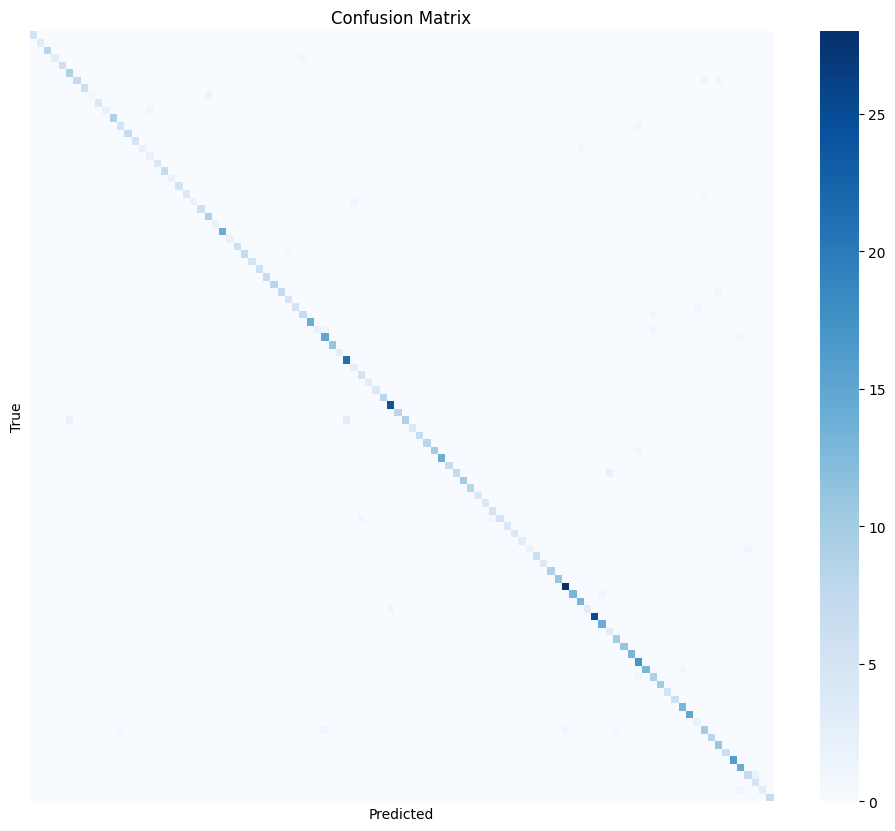

In [51]:
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [52]:
report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         8
           3       1.00      0.75      0.86         4
           4       1.00      1.00      1.00         6
           5       0.82      1.00      0.90         9
           6       1.00      0.78      0.88         9
           7       1.00      1.00      1.00         6
           8       1.00      0.33      0.50         3
           9       1.00      1.00      1.00         4
          10       1.00      0.67      0.80         3
          11       1.00      1.00      1.00         9
          12       0.83      0.83      0.83         6
          13       1.00      1.00      1.00         7
          14       1.00      1.00      1.00         5
          15       1.00      0.67      0.80         3
          16       0.67      1.00      0.80         2
          17       1.00    

In [71]:
import matplotlib.pyplot as plt
import random
import torch
from PIL import Image

def denormalize(img_tensor):
    # if you used ImageNet normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img_tensor * std + mean

In [72]:
def predict(model, image_tensor, class_names, device):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(image_tensor)
        pred = torch.argmax(out, dim=1)

    return class_names[pred.item()]

In [73]:
def show_actual_vs_pred(dataset, model, class_names, device, idx=None):
    
    if idx is None:
        idx = random.randint(0, len(dataset)-1)

    img_tensor, label = dataset[idx]

    
    pred_label = predict(model, img_tensor, class_names, device)

    true_label = class_names[label]

   
    img = denormalize(img_tensor).permute(1,2,0).cpu().numpy()
    img = img.clip(0,1)

    plt.figure(figsize=(10,5))

   
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title(f"ACTUAL\n{true_label}")
    plt.axis("off")

    
    plt.subplot(1,2,2)
    plt.imshow(img)
    plt.title(f"PREDICTED\n{pred_label}")
    plt.axis("off")

    plt.show()

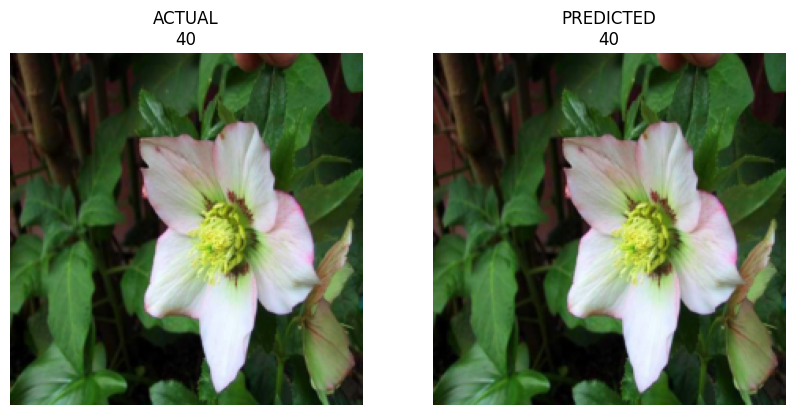

In [75]:
class_names = train_data.classes

show_actual_vs_pred(
    test_data,
    model,
    class_names,
    device
)

In [103]:
report_dict = classification_report(y_true, y_pred, output_dict=True)

print("Macro Precision:", report_dict["macro avg"]["precision"])
print("Macro Recall:", report_dict["macro avg"]["recall"])
print("Macro F1-score:", report_dict["macro avg"]["f1-score"])

Macro Precision: 0.9580629636971361
Macro Recall: 0.9397074738986504
Macro F1-score: 0.9410803054644079
